In [1]:
import numpy as np
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pymatgen.io.ase import AseAtomsAdaptor
bridge = AseAtomsAdaptor()
from sklearn.metrics import mean_absolute_error as mae
def kappa_wlmae(y_true, y_pred, p=2, log_base='e', eps=1e-12):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    # weights: full weight <=2; decay as (2/y)^p above 2
    w = np.minimum(1.0, (2.0 / np.maximum(y_true, eps))**p)
    # log error (natural or base-10)
    if log_base == 'e':
        err = np.abs(np.log(np.maximum(y_pred, eps)) - np.log(np.maximum(y_true, eps)))
    elif log_base == '10':
        err = np.abs(np.log10(np.maximum(y_pred, eps)) - np.log10(np.maximum(y_true, eps)))
    else:
        raise ValueError("log_base must be 'e' or '10'")
    return np.sum(w * err) / np.sum(w)

def symm_structure(structure):
    from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
    # Save the symm structures
    sga = SpacegroupAnalyzer(structure, symprec=1e-3)
    refined_struc = sga.get_refined_structure()
    sga = SpacegroupAnalyzer(refined_struc,symprec=0.01)
    strc_symmetry = sga.get_symmetrized_structure()
    return strc_symmetry

split = 'random_split'
#split = 'space_group_split'
#split = 'ood_split'
# Load any split
with open(f'processed_splits/{split}.pkl', 'rb') as f:
    data = pickle.load(f)
# Access features
X_train = data['X_train']
X_test = data['X_test']
structures = X_train['symmetrized_structures']  # Pymatgen Structure objects
ase_structures = [bridge.get_atoms(s) for s in structures]
structures_test = X_test['symmetrized_structures']
ase_structures_test = [bridge.get_atoms(s) for s in structures_test]

wyckoff = X_train['wyckoff_letters']
space_groups = X_train['spacegroup_numbers']
wyckoff_test = X_test['wyckoff_letters']
space_groups_test = X_test['spacegroup_numbers']
band_gaps = X_train['band_gap']  # None if no API key
band_gaps_test = X_test['band_gap']
df_X_train = pd.DataFrame(X_train)
df_X_test = pd.DataFrame(X_test)

# Access targets
y_train = data['y_train_log_klat']  # Log-transformed
y_test = data['y_test_log_klat']
y_train_original = data['y_train_klat']  # Original values
y_test_original = data['y_test_klat']
df_y_train = pd.DataFrame(y_train)
df_y_test = pd.DataFrame(y_test)

# First training structure
struc = structures[0]
print(struc.composition)
print(struc.lattice)
print(struc.density)
struc

Se18
11.310649 0.000000 0.000000
-5.655324 9.795309 0.000000
0.000000 0.000000 4.839523
4.401700513167085 g cm^-3


SymmetrizedStructure
Full Formula (Se18)
Reduced Formula: Se
Spacegroup: R-3 (148)
abc   :  11.310649  11.310649   4.839523
angles:  90.000000  90.000000 120.000000
Sites (18)
  #  SP          a         b         c  Wyckoff
---  ----  -------  --------  --------  ---------
  0  Se    0.95988  0.796532  0.889264  18f

In [2]:
import pickle
with open(f'mace_omat/{split}_mace_descriptors_train.pkl', 'rb') as f:
    mace_descriptors = pickle.load(f)
with open(f'mace_omat/{split}_mace_descriptors_test.pkl', 'rb') as f:
    mace_descriptors_test = pickle.load(f)

print(len(mace_descriptors), len(mace_descriptors_test))

5563 1403


In [3]:
x_train = np.array([np.mean(desc, axis=0) for desc in mace_descriptors])
x_test = np.array([np.mean(desc, axis=0) for desc in mace_descriptors_test])
print(x_train.shape, x_test.shape)

(5563, 256) (1403, 256)


2025-11-03 09:52:50.991879: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-03 09:52:53.384618: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-03 09:52:53.385402: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-03 09:52:53.393948: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-03 09:52:54.440424: I tensorflow/core/platform/cpu_feature_g

Epoch 1/600
87/87 [==============================] - 2s 6ms/step - loss: 1.0730 - mae: 1.0730 - r2_score: 0.1001 - val_loss: 0.7376 - val_mae: 0.7376 - val_r2_score: 0.4446
Epoch 2/600
87/87 [==============================] - 0s 4ms/step - loss: 0.8749 - mae: 0.8749 - r2_score: 0.3849 - val_loss: 0.7065 - val_mae: 0.7065 - val_r2_score: 0.4899
Epoch 3/600
87/87 [==============================] - 0s 4ms/step - loss: 0.8047 - mae: 0.8047 - r2_score: 0.4710 - val_loss: 0.6389 - val_mae: 0.6389 - val_r2_score: 0.5662
Epoch 4/600
87/87 [==============================] - 0s 4ms/step - loss: 0.7662 - mae: 0.7662 - r2_score: 0.5088 - val_loss: 0.6499 - val_mae: 0.6499 - val_r2_score: 0.5563
Epoch 5/600
87/87 [==============================] - 0s 4ms/step - loss: 0.7336 - mae: 0.7336 - r2_score: 0.5417 - val_loss: 0.6011 - val_mae: 0.6011 - val_r2_score: 0.5930
Epoch 6/600
87/87 [==============================] - 0s 4ms/step - loss: 0.7083 - mae: 0.7083 - r2_score: 0.5733 - val_loss: 0.6214 - v

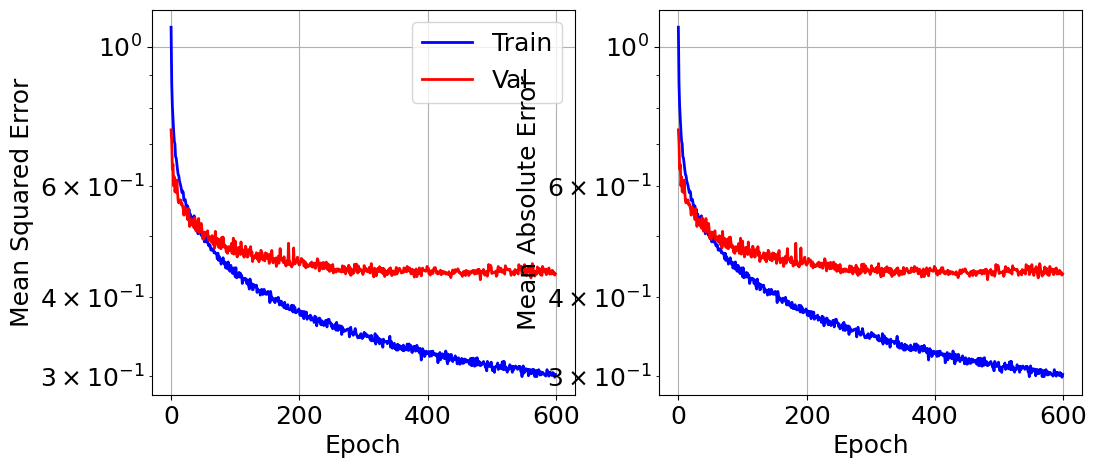

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks, optimizers
import keras

# --- Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# x_train: shape (N, 256), y_train: shape (N,)
# Ensure y is float32
y_train = y_train.astype("float32")

# --- Feature normalization (adapts on the training data)
normalizer = layers.Normalization()
normalizer.adapt(x_train)

# --- R^2 metric
@tf.function
def r2_score(y_true, y_pred):
    ss_res = tf.reduce_sum(tf.square(y_true - y_pred))
    mean = tf.reduce_mean(y_true)
    ss_tot = tf.reduce_sum(tf.square(y_true - mean))
    return 1.0 - ss_res / (ss_tot + tf.keras.backend.epsilon())

# --- Model (Functional API)
inputs = keras.Input(shape=(x_train.shape[1],), name="x")
x = normalizer(inputs)

# Block 1
x = layers.Dense(
    256,
    activation="gelu",
    kernel_initializer="he_normal",
)(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.2)(x)

# Block 2
x = layers.Dense(
    128,
    activation="gelu",
    kernel_initializer="he_normal",
)(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.2)(x)

# Block 3 (smaller)
x = layers.Dense(
    64,
    activation="gelu",
    kernel_initializer="he_normal",
)(x)
x = layers.Dropout(0.1)(x)

# Output (linear for regression)
outputs = layers.Dense(1, activation="linear", name="y")(x)

model = keras.Model(inputs, outputs, name="mlp_regressor")

# --- Optimizer: AdamW (decoupled weight decay)
# If your TF version lacks AdamW, fall back to Adam(1e-3) + kernel_regularizer=l2.
opt = optimizers.AdamW(learning_rate=0.0005, weight_decay=0.0001)

model.compile(
    optimizer=opt,
    loss="mae",
    metrics=[keras.metrics.MeanAbsoluteError(name="mae"), r2_score],
)

# --- Callbacks
cbs = [
    callbacks.EarlyStopping(
        monitor="val_loss", patience=20, restore_best_weights=True
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6
    ),
    callbacks.ModelCheckpoint(
        "best_model.keras", monitor="val_loss", save_best_only=True
    ),
]


# Train the model using the training and validtaion set 
history = model.fit(x_train, y_train, validation_data=(x_test, y_test),
                    batch_size=64,
                    epochs=600)

x_train_pred = model.predict(x_train)
x_test_pred = model.predict(x_test)
model_name ='mlp_regressor'

# Plotting the loss function and mean squared error for each epoch 
# to test for overtaining and preformance
fig2, ax2 = plt.subplots(figsize=(12,5), ncols=2)
font_size = 18
train_color = 'b'
val_color = 'r'
linewidth = 2
ax2[0].plot(history.history['loss'],color=train_color, label='Train',linewidth=linewidth)
ax2[0].plot(history.history['val_loss'],color=val_color, label='Val',linewidth=linewidth)
ax2[0].legend(fontsize=font_size)
# plt.ylabel('log_loss')
ax2[0].set_ylabel('Mean Squared Error',fontsize=font_size)
ax2[0].set_xlabel('Epoch',fontsize=font_size)
ax2[0].tick_params(axis='both', which='major', labelsize=font_size)
ax2[0].tick_params(axis='both', which='minor', labelsize=font_size)
ax2[0].grid(True)
ax2[0].set_yscale('log')

ax2[1].plot(history.history['mae'],color=train_color, label='train',linewidth=linewidth)
ax2[1].plot(history.history['val_mae'],color=val_color, label='val',linewidth=linewidth)
#ax2[1].legend()
# plt.ylabel('log_loss')
ax2[1].set_ylabel('Mean Absolute Error',fontsize=font_size)
ax2[1].set_xlabel('Epoch',fontsize=font_size)
ax2[1].tick_params(axis='both', which='major', labelsize=font_size)
ax2[1].tick_params(axis='both', which='minor', labelsize=font_size)
ax2[1].grid(True)
ax2[1].set_yscale('log')


Text(0.5, 0.98, 'ANN regression')

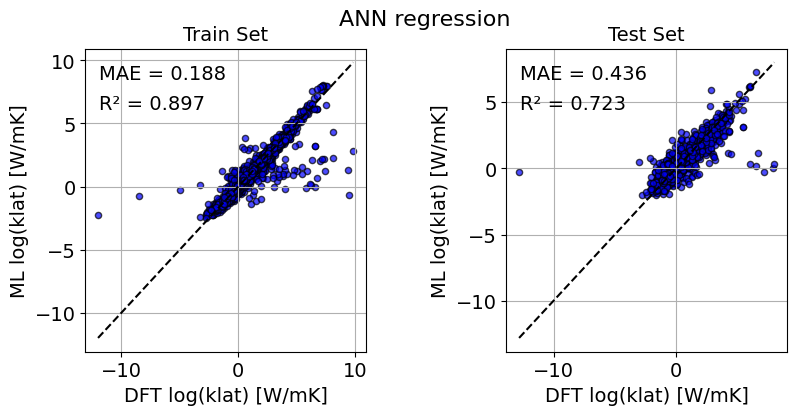

In [5]:
# Plot the scatter plot of the relative error
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

def kappa_wlmae(y_true, y_pred, p=2, log_base='e', eps=1e-12):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    # weights: full weight <=2; decay as (2/y)^p above 2
    w = np.minimum(1.0, (2.0 / np.maximum(y_true, eps))**p)
    # log error (natural or base-10)
    if log_base == 'e':
        err = np.abs(np.log(np.maximum(y_pred, eps)) - np.log(np.maximum(y_true, eps)))
    elif log_base == '10':
        err = np.abs(np.log10(np.maximum(y_pred, eps)) - np.log10(np.maximum(y_true, eps)))
    else:
        raise ValueError("log_base must be 'e' or '10'")
    return np.sum(w * err) / np.sum(w)


inches_to_cm = 2.54
figsize = (23/inches_to_cm, 10/inches_to_cm)

colors = {'Interstitial': 'b', 'Substitution': 'r', 'Vacancy': 'g'}
markers = {'Interstitial': 'o', 'Substitution': 's', 'Vacancy': '^'}
alpha = 0.5
font_size = 20
legend_font = font_size-5
handlelength=0.5
col = 0.5
han = 0.3
wspace=0.5 

fig1, ax1 = plt.subplots(1,2, figsize=figsize,gridspec_kw = {'wspace':wspace})
font_size = 14

ax1[0].plot([min(y_train),max(y_train)],[min(y_train),max(y_train)],'k--')
ax1[1].plot([min(y_test),max(y_test)],[min(y_test),max(y_test)],'k--')

ax1[0].scatter(y_train,x_train_pred, color='blue', s=20, alpha=0.7, edgecolors='k')

ax1[1].scatter(y_test,x_test_pred, color='blue', s=20, alpha=0.7, edgecolors='k')
ax1[0].set_xlabel('DFT log(klat) [W/mK]', fontsize=font_size)
ax1[0].set_ylabel('ML log(klat) [W/mK]', fontsize=font_size)
ax1[1].set_xlabel('DFT log(klat) [W/mK]', fontsize=font_size)
ax1[1].set_ylabel('ML log(klat) [W/mK]', fontsize=font_size)
ax1[0].set_title('Train Set', fontsize=font_size)
ax1[1].set_title('Test Set', fontsize=font_size)
ax1[0].tick_params(axis='both', which='major', labelsize=font_size)
ax1[1].tick_params(axis='both', which='major', labelsize=font_size)

mae_train = mae(x_train_pred,y_train)
mae_test = mae(x_test_pred,y_test)
ax1[1].text(0.05, 0.95, f'MAE = {mae_test:.3f}', transform=ax1[1].transAxes, fontsize=font_size, verticalalignment='top')
ax1[0].text(0.05, 0.95, f'MAE = {mae_train:.3f}', transform=ax1[0].transAxes, fontsize=font_size, verticalalignment='top')

#R2_train = kappa_wlmae(y_train, x_train_pred)
#R2_test = kappa_wlmae(y_test, x_test_pred)
#ax1[0].text(0.05, 0.85, f'W-LMAE = {R2_train:.3f}', transform=ax1[0].transAxes, fontsize=font_size, verticalalignment='top')
#ax1[1].text(0.05, 0.85, f'W-LMAE = {R2_test:.3f}', transform=ax1[1].transAxes, fontsize=font_size, verticalalignment='top')

R2_train = r2_score(y_train, x_train_pred)
R2_test = r2_score(y_test, x_test_pred)
ax1[0].text(0.05, 0.85, f'R² = {R2_train:.3f}', transform=ax1[0].transAxes, fontsize=font_size, verticalalignment='top')
ax1[1].text(0.05, 0.85, f'R² = {R2_test:.3f}', transform=ax1[1].transAxes, fontsize=font_size, verticalalignment='top')

ax1[0].grid(True)
ax1[1].grid(True)
fig1.suptitle(model_name, fontsize=font_size+2)

